In [1]:
from scipy.io import mmread
from scipy.sparse import csr_matrix
import anndata as ad
import pandas as pd
import scvi
import numpy as np
import scanpy as sc
scvi.settings.seed = 420
import os, sys, time, gc
from os.path import join

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:30: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(
Global seed set to 0
Global seed set to 420


In [2]:
data_dir = '../../../data/processed/Mux-VisiumHD-HE'

ad_mux_rna = sc.read_h5ad(join(data_dir, 'Mux/ad_rna.h5ad'))
ad_mux_atac = sc.read_h5ad(join(data_dir, 'Mux/ad_atac.h5ad'))

ad_vhd_rna = sc.read_h5ad(join(data_dir, 'VisiumHD/ad_rna.h5ad'))
ad_vhe_rna = sc.read_h5ad(join(data_dir, 'VisiumHE/ad_rna.h5ad')) 

In [3]:
ad_rna_all = sc.concat([ad_mux_rna, ad_vhd_rna, ad_vhe_rna])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Slice')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

# ac.pp.tfidf(ad_atac_all, scale_factor=1e4)
sc.pp.highly_variable_genes(ad_mux_atac, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hvp_names = ad_mux_atac.var.query('highly_variable').index.to_numpy()

In [4]:
ad_mux_rna = ad_mux_rna[:, hvg_names].copy()
ad_vhd_rna = ad_vhd_rna[:, hvg_names].copy()
ad_vhe_rna = ad_vhe_rna[:, hvg_names].copy()

ad_mux_atac = ad_mux_atac[:, hvp_names].copy()

In [5]:
for adx in [ad_mux_rna, ad_vhd_rna, ad_vhe_rna]:
    adx.var['modality'] = ['Gene Expression']*adx.shape[1]
for adx in [ad_mux_atac]:
    adx.var['modality'] = ['Peaks']*adx.shape[1]

In [6]:
def colcat(ads):
    adx = sc.concat(ads, axis=1)
    adx.obs = ads[0].obs.copy()
    return adx

def rowcat(ads):
    adx = sc.concat(ads)
    adx.var = ads[0].var.copy()
    return adx

In [7]:
ad_mux = colcat([ad_mux_rna, ad_mux_atac])

In [8]:
ad_mux.obs['modality'] = 'paired'

ad_vh = rowcat([ad_vhd_rna, ad_vhe_rna])
ad_vh.obs['modality'] = 'geneExpr'

In [11]:
# We can now use the organizing method from scvi to concatenate these anndata
adata_mvi = scvi.data.organize_multiome_anndatas(multi_anndata=ad_mux, 
                                                 rna_anndata=ad_vh,
                                                 atac_anndata=None)

print(adata_mvi.shape)

adata_mvi = adata_mvi[:, adata_mvi.var["modality"].argsort()].copy()
scvi.model.MULTIVI.setup_anndata(adata_mvi, batch_key="modality", categorical_covariate_keys=['Slice'])

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


(111305, 57125)


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [12]:
model = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata_mvi.var["modality"] == "Peaks").sum(),
)
model.view_anndata_setup()

model.train()

latent = model.get_latent_representation()

# np.savetxt(arguments[3]+"/MultiVI.csv", latent, delimiter=',')

Anndata setup with scvi-tools version 0.15.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'modality',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['Slice'],
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_cells          │ 111305 │
│          n_vars          │ 57125  │
│         n_batch          │   2    │
│         n_labels         │   1    │
│ n_extra_categorical_covs │   1    │
│ n_extra_continuous_covs  │   0    │
└──────────────────────────┴────────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│         labels         │         adata.obs['_scvi_labels']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
└────────────────────────┴────────────────────────────────────────────┘

...

          extra_categorical_covs State Registry          
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Slice'] │     hd     │          0          │
│                    │     he     │          1          │
│                    │    mux     │          2          │
│                    │            │                     │
└────────────────────┴────────────┴─────────────────────┘

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/500:   0%|                                                                                                                                                                        | 0/500 [00:00<?, ?it/s]

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scvi/module/_multivae.py:567: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2981.)
  x = torch.where(mask_expr.T, x_expr.T, x_acc.T).T


Epoch 283/500:  57%|███████████████████████████████████████████████████████████████████████████▎                                                         | 283/500 [4:29:24<3:26:34, 57.12s/it, loss=757, v_num=1]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1538.001. Signaling Trainer to stop.


In [13]:
adata_mvi

AnnData object with n_obs × n_vars = 111305 × 57125
    obs: 'Sample', 'Slice', 'mclust_16', 'mclust_20', 'mclust_24', 'louvain_0.5', 'louvain_0.6', 'louvain_0.8', 'leiden_0.5', 'leiden_0.6', 'leiden_0.8', 'modality', '_scvi_batch', '_scvi_labels'
    var: 'modality'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_emb', 'dimred_bc', 'emb', 'seurat_cca', 'seurat_cca_smth', 'spatial', '_scvi_extra_categorical_covs'

In [14]:
adata_mvi.obsm['emb'] = latent.copy()
sc.pp.neighbors(adata_mvi, use_rep='emb', n_neighbors=15)
sc.tl.umap(adata_mvi)

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


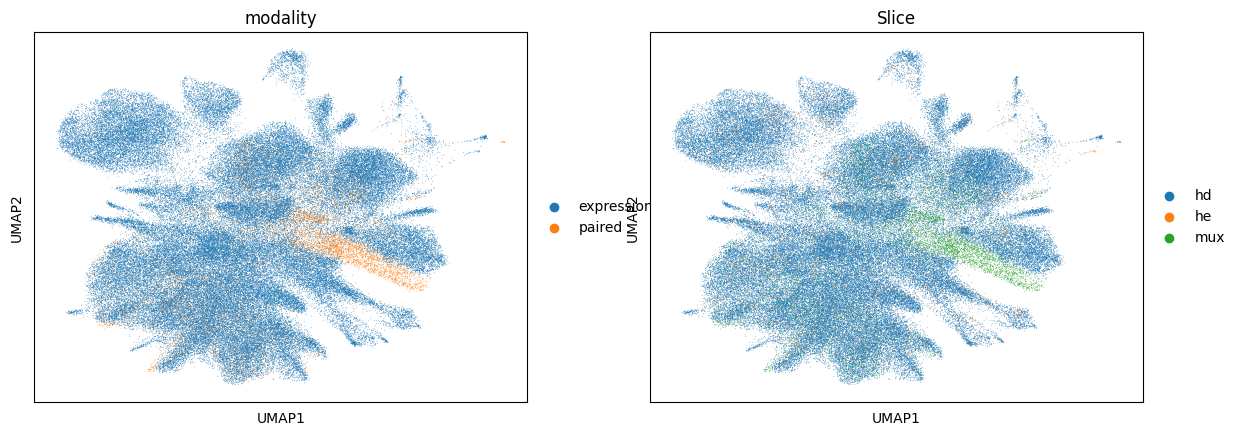

In [15]:
sc.pl.umap(adata_mvi, color=['modality', 'Slice'])

In [16]:
anal_dir = '../../../results/embeddings/MultiVI/Mux-VisiumHD-HE'
os.makedirs(anal_dir, exist_ok=True)

df = pd.DataFrame(latent, index=[x.rsplit('_', 1)[0] for x in adata_mvi.obs_names])
df.to_csv(join(anal_dir, 'df_emb.csv'))